Support Vector Machine (SVM) and Naïve Bayes - assignment  

1. What is a Support Vector Machine (SVM)?

SVM is a supervised machine learning algorithm used for classification and regression. It finds the optimal hyperplane that separates classes with the maximum margin.

2.Difference Between Hard Margin and Soft Margin SVM

Hard margin assumes perfectly separable data and allows no errors. Soft margin allows misclassification using slack variables and is more robust to noise.

3.Mathematical Intuition Behind SVM

SVM maximizes the margin between classes while minimizing the norm of the weight vector. This ensures the best separation and generalization.

4.Role of Lagrange Multipliers in SVM

They convert constrained optimization into a solvable dual problem and help identify support vectors.

5.What are Support Vectors?

Support vectors are the closest data points to the decision boundary. They define the hyperplane.

6.What is Support Vector Classifier (SVC)?

SVC is the classification version of SVM used to separate classes using optimal hyperplanes.

7.What is Support Vector Regressor (SVR)?

SVR is the regression version of SVM that fits data within a tolerance margin.

8.What is the Kernel Trick?

The kernel trick allows SVM to handle nonlinear data by mapping it into higher-dimensional space implicitly.

9.Linear vs Polynomial vs RBF Kernel

Linear kernel is used for linear data. Polynomial kernel captures feature interactions. RBF kernel handles complex nonlinear relationships.

10.Effect of C parameter

C controls the trade-off between margin size and classification error.



11.Effect of Gamma parameter

Gamma controls how far influence of a single training example reaches.

12.What is Naïve Bayes?

Naïve Bayes is a probabilistic classifier based on Bayes' theorem and independence assumption.

13.What is Bayes' Theorem?

It calculates posterior probability using prior probability and likelihood.

14.Gaussian vs Multinomial vs Bernoulli Naïve Bayes

Gaussian is for continuous data, Multinomial for counts, Bernoulli for binary features.

15.When to use Gaussian Naïve Bayes?

When features are continuous and normally distributed.

16.Key Assumptions of Naïve Bayes

Features are conditionally independent given the class.

17.Advantages and Disadvantages of Naïve Bayes

It is fast and efficient but assumes independence which may not be realistic.

18.Why Naïve Bayes is good for text classification?

It works well with high-dimensional sparse data like word counts.

19.Compare SVM and Naïve Bayes

SVM is more accurate for complex data. Naïve Bayes is faster and efficient for text.

20.Laplace Smoothing

It prevents zero probabilities by adding 1 to all feature counts.



Prectical


In [1]:
  ##21.Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy:


# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create SVM classifier (using RBF kernel)
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the model
svm_classifier.fit(X_train, y_train)

# Make predictions
y_pred = svm_classifier.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [2]:
# # Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create SVM classifier with Linear kernel
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

# Create SVM classifier with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)

# Make predictions
y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# Print results
print("Linear Kernel SVM Accuracy:", accuracy_linear)
print("RBF Kernel SVM Accuracy:", accuracy_rbf)

# Compare results
if accuracy_linear > accuracy_rbf:
    print("Linear kernel performs better.")
elif accuracy_linear < accuracy_rbf:
    print("RBF kernel performs better.")
else:
    print("Both kernels perform equally.")



Linear Kernel SVM Accuracy: 1.0
RBF Kernel SVM Accuracy: 0.8055555555555556
Linear kernel performs better.


In [3]:
##23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE):

 # Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load the California Housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SVR model (RBF kernel)
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

# Train the model
svr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svr_model.predict(X_test_scaled)

# Evaluate using Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Print results
print("Mean Squared Error (MSE):", mse)



Mean Squared Error (MSE): 0.32449462225743636


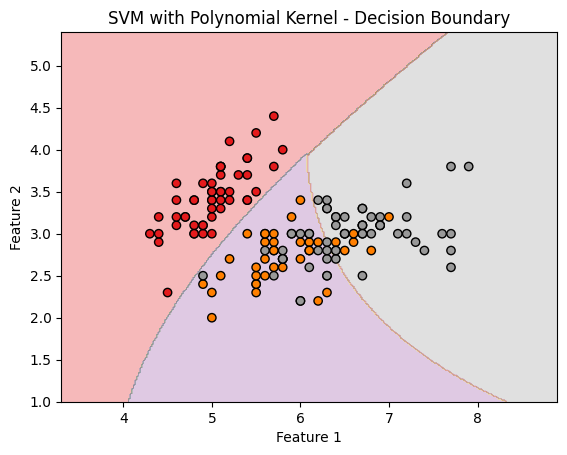

In [4]:
# 24.Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary:

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Take only first two features for visualization
y = iris.target

# Create SVM classifier with Polynomial kernel
svm_poly = SVC(kernel='poly', degree=3, C=1.0)
svm_poly.fit(X, y)

# Create a mesh grid for plotting decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict over mesh grid
Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM with Polynomial Kernel - Decision Boundary")
plt.show()

In [5]:
# 25.Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy:

 # Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Gaussian Naïve Bayes model
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, y_train)

# Make predictions
y_pred = gnb.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[40  3]
 [ 0 71]]


In [6]:
# 26.Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.
# Import required libraries
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Load 20 Newsgroups dataset (subset for faster training)
categories = ['sci.space', 'rec.sport.baseball', 'comp.graphics', 'talk.politics.misc']
newsgroups = fetch_20newsgroups(subset='all', categories=categories)

X = newsgroups.data
y = newsgroups.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text data into numerical features using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Create Multinomial Naïve Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_counts, y_train)

# Make predictions
y_pred = nb_model.predict(X_test_counts)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=newsgroups.target_names))


Accuracy: 0.982573726541555

Classification Report:
                     precision    recall  f1-score   support

     comp.graphics       0.97      0.99      0.98       210
rec.sport.baseball       0.99      0.99      0.99       192
         sci.space       0.99      0.97      0.98       196
talk.politics.misc       0.99      0.98      0.98       148

          accuracy                           0.98       746
         macro avg       0.98      0.98      0.98       746
      weighted avg       0.98      0.98      0.98       746



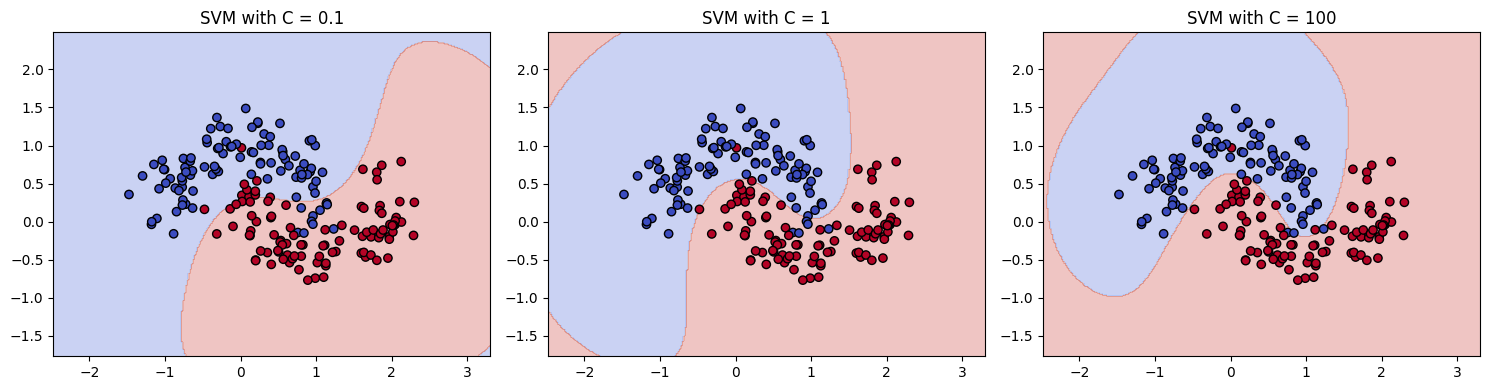

In [7]:
# 27.Write a Python program to train an SVM Classifier with different C values and compare the decision
# boundaries visually=
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# Generate synthetic dataset
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Different C values to compare
C_values = [0.1, 1, 100]

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Plot decision boundaries for each C
plt.figure(figsize=(15, 4))

for i, C in enumerate(C_values):
    svm = SVC(kernel='rbf', C=C, gamma='scale')
    svm.fit(X, y)

    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(f"SVM with C = {C}")

plt.tight_layout()
plt.show()

In [8]:
# 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with
# binary features=
# Import required libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate synthetic binary classification dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=0,
    random_state=42
)

# Convert features to binary (0 or 1)
X_binary = (X > 0).astype(int)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y, test_size=0.2, random_state=42
)

# Create Bernoulli Naïve Bayes model
bnb = BernoulliNB()

# Train the model
bnb.fit(X_train, y_train)

# Make predictions
y_pred = bnb.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.67

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.67      0.68       104
           1       0.65      0.67      0.66        96

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.67      0.67      0.67       200

Confusion Matrix:
 [[70 34]
 [32 64]]


In [9]:
# 29. Write a Python program to apply feature scaling before training an SVM model and compare results with
# unscaled data=
# Import required libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 1️ Train SVM without scaling
# -----------------------------
svm_unscaled = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_unscaled.fit(X_train, y_train)

y_pred_unscaled = svm_unscaled.predict(X_test)
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

# -----------------------------
# 2️ Train SVM with scaling
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_scaled = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = svm_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

# -----------------------------
# Print Results
# -----------------------------
print("Accuracy without scaling:", accuracy_unscaled)
print("Accuracy with scaling:", accuracy_scaled)

# Compare results
if accuracy_scaled > accuracy_unscaled:
    print("\nScaling improved model performance.")
elif accuracy_scaled < accuracy_unscaled:
    print("\nScaling reduced model performance.")
else:
    print("\nScaling made no difference.")

Accuracy without scaling: 0.8055555555555556
Accuracy with scaling: 1.0

Scaling improved model performance.


In [10]:
# 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and
# after Laplace Smoothing
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 1️ GaussianNB without smoothing (very small var_smoothing)
# ----------------------------
gnb_no_smooth = GaussianNB(var_smoothing=1e-12)
gnb_no_smooth.fit(X_train, y_train)

y_pred_no_smooth = gnb_no_smooth.predict(X_test)
accuracy_no_smooth = accuracy_score(y_test, y_pred_no_smooth)

# ----------------------------
# 2️ GaussianNB with smoothing (default var_smoothing)
# ----------------------------
gnb_smooth = GaussianNB(var_smoothing=1e-9)
gnb_smooth.fit(X_train, y_train)

y_pred_smooth = gnb_smooth.predict(X_test)
accuracy_smooth = accuracy_score(y_test, y_pred_smooth)

# ----------------------------
# Compare results
# ----------------------------
print("Accuracy without smoothing:", accuracy_no_smooth)
print("Accuracy with smoothing:", accuracy_smooth)

# Check prediction differences
difference = (y_pred_no_smooth != y_pred_smooth).sum()
print("Number of different predictions:", difference)

Accuracy without smoothing: 0.9649122807017544
Accuracy with smoothing: 0.9736842105263158
Number of different predictions: 1


In [11]:
# 31 Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C,
# gamma, kernel)
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define SVM classifier
svm = SVC()

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

# Apply GridSearchCV
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,       # 5-fold cross-validation
    verbose=2,
    n_jobs=-1
)

# Train model and search for best hyperparameters
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate on test set
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)

print("\nTest Set Accuracy:", accuracy_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}
Best Cross-Validation Accuracy: 0.9583333333333334

Test Set Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
# 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and
# check it improve accuracy=
# Import required libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate an imbalanced binary dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=0,
    n_classes=2,
    weights=[0.9, 0.1],  # 90% of class 0, 10% of class 1
    random_state=42
)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 1️ SVM without class weighting
# -----------------------------
svm_no_weight = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_no_weight.fit(X_train, y_train)
y_pred_no_weight = svm_no_weight.predict(X_test)

accuracy_no_weight = accuracy_score(y_test, y_pred_no_weight)
print("Accuracy without class weighting:", accuracy_no_weight)
print("Classification Report without weighting:\n", classification_report(y_test, y_pred_no_weight))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_no_weight))

# -----------------------------
# 2️ SVM with class weighting
# -----------------------------
svm_weighted = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
svm_weighted.fit(X_train, y_train)
y_pred_weighted = svm_weighted.predict(X_test)

accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
print("\nAccuracy with class weighting:", accuracy_weighted)
print("Classification Report with weighting:\n", classification_report(y_test, y_pred_weighted))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_weighted))

Accuracy without class weighting: 0.96
Classification Report without weighting:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       176
           1       1.00      0.67      0.80        24

    accuracy                           0.96       200
   macro avg       0.98      0.83      0.89       200
weighted avg       0.96      0.96      0.96       200

Confusion Matrix:
 [[176   0]
 [  8  16]]

Accuracy with class weighting: 0.93
Classification Report with weighting:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       176
           1       0.67      0.83      0.74        24

    accuracy                           0.93       200
   macro avg       0.82      0.89      0.85       200
weighted avg       0.94      0.93      0.93       200

Confusion Matrix:
 [[166  10]
 [  4  20]]


In [ ]:
# 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data=
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 1️ Load Dataset
# -----------------------------
# Dataset URL: https://archive.ics.uci.edu/ml/datasets/sms+spam+collection
# Assume the file 'SMSSpamCollection' is downloaded locally
data = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

# Encode labels: spam=1, ham=0
data['label_num'] = data.label.map({'ham':0, 'spam':1})

X = data['message']
y = data['label_num']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Text Vectorization
# -----------------------------
# Convert text into numerical features
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

# Optional: Use TF-IDF weighting
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

# -----------------------------
# 3️ Train Multinomial Naïve Bayes
# -----------------------------
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# -----------------------------
# 4️ Make Predictions
# -----------------------------
y_pred = nb_model.predict(X_test_tfidf)

# -----------------------------
# 5️ Evaluate Performance
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['ham','spam']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [14]:
# 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and
# compare their accuracy=
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️ Load Dataset
# -----------------------------
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train SVM Classifier
# -----------------------------
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# -----------------------------
# 3️ Train Gaussian Naïve Bayes Classifier
# -----------------------------
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
y_pred_gnb = gnb_model.predict(X_test)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)

# -----------------------------
# 4️ Print Results
# -----------------------------
print("SVM Accuracy:", accuracy_svm)
print("Gaussian Naïve Bayes Accuracy:", accuracy_gnb)

print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))
print("Gaussian Naïve Bayes Classification Report:\n", classification_report(y_test, y_pred_gnb))

SVM Accuracy: 1.0
Gaussian Naïve Bayes Accuracy: 1.0

SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Gaussian Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
# 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare
# results
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️ Load Dataset
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train Naïve Bayes on all features
# -----------------------------
gnb_all = GaussianNB()
gnb_all.fit(X_train, y_train)
y_pred_all = gnb_all.predict(X_test)
accuracy_all = accuracy_score(y_test, y_pred_all)

print("Accuracy with all features:", accuracy_all)
print("\nClassification Report (all features):\n", classification_report(y_test, y_pred_all))

# -----------------------------
# 3️ Feature Selection (Select top k features)
# -----------------------------
# GaussianNB expects non-negative features for chi2, so shift data to positive
X_train_positive = X_train - X_train.min() + 1
X_test_positive = X_test - X_train.min() + 1  # use same shift as training

k = 10  # number of top features to select
selector = SelectKBest(score_func=chi2, k=k)
X_train_selected = selector.fit_transform(X_train_positive, y_train)
X_test_selected = selector.transform(X_test_positive)

# -----------------------------
# 4️ Train Naïve Bayes on selected features
# -----------------------------
gnb_selected = GaussianNB()
gnb_selected.fit(X_train_selected, y_train)
y_pred_selected = gnb_selected.predict(X_test_selected)
accuracy_selected = accuracy_score(y_test, y_pred_selected)

print("\nAccuracy with top", k, "features:", accuracy_selected)
print("\nClassification Report (top features):\n", classification_report(y_test, y_pred_selected))

Accuracy with all features: 0.9736842105263158

Classification Report (all features):
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Accuracy with top 10 features: 0.956140350877193

Classification Report (top features):
               precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



In [16]:

# 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO)
# strategies on the Wine dataset and compare their accuracy
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️ Load Wine Dataset
# -----------------------------
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train SVM using One-vs-Rest (OvR)
# -----------------------------
svm_ovr = OneVsRestClassifier(SVC(kernel='rbf', C=1.0, gamma='scale'))
svm_ovr.fit(X_train, y_train)
y_pred_ovr = svm_ovr.predict(X_test)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

print("One-vs-Rest (OvR) SVM Accuracy:", accuracy_ovr)
print("Classification Report (OvR):\n", classification_report(y_test, y_pred_ovr))

# -----------------------------
# 3️ Train SVM using One-vs-One (OvO)
# -----------------------------
svm_ovo = OneVsOneClassifier(SVC(kernel='rbf', C=1.0, gamma='scale'))
svm_ovo.fit(X_train, y_train)
y_pred_ovo = svm_ovo.predict(X_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

print("One-vs-One (OvO) SVM Accuracy:", accuracy_ovo)
print("Classification Report (OvO):\n", classification_report(y_test, y_pred_ovo))

One-vs-Rest (OvR) SVM Accuracy: 0.7777777777777778
Classification Report (OvR):
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       0.74      1.00      0.85        14
           2       0.00      0.00      0.00         8

    accuracy                           0.78        36
   macro avg       0.52      0.67      0.58        36
weighted avg       0.61      0.78      0.68        36

One-vs-One (OvO) SVM Accuracy: 0.8333333333333334
Classification Report (OvO):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.83      0.71      0.77        14
           2       0.60      0.75      0.67         8

    accuracy                           0.83        36
   macro avg       0.81      0.82      0.81        36
weighted avg       0.85      0.83      0.84        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
# 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast
# Cancer dataset and compare their accuracy
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️ Load Wine Dataset
# -----------------------------
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train SVM using One-vs-Rest (OvR)
# -----------------------------
svm_ovr = OneVsRestClassifier(SVC(kernel='rbf', C=1.0, gamma='scale'))
svm_ovr.fit(X_train, y_train)
y_pred_ovr = svm_ovr.predict(X_test)
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

print("One-vs-Rest (OvR) SVM Accuracy:", accuracy_ovr)
print("Classification Report (OvR):\n", classification_report(y_test, y_pred_ovr))

# -----------------------------
# 3️ Train SVM using One-vs-One (OvO)
# -----------------------------
svm_ovo = OneVsOneClassifier(SVC(kernel='rbf', C=1.0, gamma='scale'))
svm_ovo.fit(X_train, y_train)
y_pred_ovo = svm_ovo.predict(X_test)
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

print("One-vs-One (OvO) SVM Accuracy:", accuracy_ovo)
print("Classification Report (OvO):\n", classification_report(y_test, y_pred_ovo))

One-vs-Rest (OvR) SVM Accuracy: 0.7777777777777778
Classification Report (OvR):
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       0.74      1.00      0.85        14
           2       0.00      0.00      0.00         8

    accuracy                           0.78        36
   macro avg       0.52      0.67      0.58        36
weighted avg       0.61      0.78      0.68        36

One-vs-One (OvO) SVM Accuracy: 0.8333333333333334
Classification Report (OvO):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.83      0.71      0.77        14
           2       0.60      0.75      0.67         8

    accuracy                           0.83        36
   macro avg       0.81      0.82      0.81        36
weighted avg       0.85      0.83      0.84        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the
# average accuracy
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️ Load Breast Cancer Dataset
# -----------------------------
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Define kernels to test
# -----------------------------
kernels = ['linear', 'poly', 'rbf']
results = {}

# -----------------------------
# 3️ Train and evaluate SVM for each kernel
# -----------------------------
for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, gamma='scale')
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[kernel] = accuracy
    print(f"Kernel: {kernel}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print("-"*50)

# -----------------------------
# 4️ Summary of Accuracies
# -----------------------------
print("Summary of Accuracies:")
for k, acc in results.items():
    print(f"{k} kernel: {acc}")

Kernel: linear
Accuracy: 0.956140350877193
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--------------------------------------------------
Kernel: poly
Accuracy: 0.9473684210526315
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

--------------------------------------------------
Kernel: rbf
Accuracy: 0.9473684210526315
Classification Report:
              precision    recall  f1-score   sup

In [19]:
# 39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare
# performance
# Import required libraries
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# -----------------------------
# 1️ Load Iris Dataset
# -----------------------------
iris = datasets.load_iris()
X = iris.data
y = iris.target

# -----------------------------
# 2️ Define SVM Classifier
# -----------------------------
svm = SVC(kernel='rbf', C=1.0, gamma='scale')

# -----------------------------
# 3️ Stratified K-Fold Cross-Validation
# -----------------------------
k = 5  # Number of folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Compute cross-validation scores
scores = cross_val_score(svm, X, y, cv=skf, scoring='accuracy')

# -----------------------------
# 4️ Print Results
# -----------------------------
print(f"Accuracy for each fold: {scores}")
print(f"Average Accuracy: {np.mean(scores)}")


Accuracy for each fold: [1.         0.96666667 0.93333333 1.         0.93333333]
Average Accuracy: 0.9666666666666668


In [20]:
# 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and
# compare accuracy
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️ Load Breast Cancer Dataset
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train SVM on all features
# -----------------------------
svm_all = SVC(kernel='linear', C=1.0)
svm_all.fit(X_train, y_train)
y_pred_all = svm_all.predict(X_test)
accuracy_all = accuracy_score(y_test, y_pred_all)

print("Accuracy with all features:", accuracy_all)
print("\nClassification Report (all features):\n", classification_report(y_test, y_pred_all))

# -----------------------------
# 3️ Perform Recursive Feature Elimination (RFE)
# -----------------------------
# Use SVM with linear kernel as estimator for RFE
svm_rfe = SVC(kernel='linear', C=1.0)
n_features_to_select = 10  # Select top 10 features
rfe = RFE(estimator=svm_rfe, n_features_to_select=n_features_to_select)
rfe.fit(X_train, y_train)

# Transform training and testing data
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# -----------------------------
# 4️ Train SVM on selected features
# -----------------------------
svm_selected = SVC(kernel='linear', C=1.0)
svm_selected.fit(X_train_rfe, y_train)
y_pred_selected = svm_selected.predict(X_test_rfe)
accuracy_selected = accuracy_score(y_test, y_pred_selected)

print("\nAccuracy with top", n_features_to_select, "features (RFE):", accuracy_selected)
print("\nClassification Report (RFE-selected features):\n", classification_report(y_test, y_pred_selected))

Accuracy with all features: 0.956140350877193

Classification Report (all features):
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Accuracy with top 10 features (RFE): 0.9736842105263158

Classification Report (RFE-selected features):
               precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [21]:
# 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and
# F1-Score instead of accuracy
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# -----------------------------
# 1️ Load Dataset
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 2️ Train SVM Classifier
# -----------------------------
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# -----------------------------
# 3️ Make Predictions
# -----------------------------
y_pred = svm_model.predict(X_test)

# -----------------------------
# 4 Evaluate Performance
# -----------------------------
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Precision: 0.922077922077922
Recall: 1.0
F1-Score: 0.9594594594594594

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [22]:
# 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss
# (Cross-Entropy Loss)=
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss

# -----------------------------
# 1️ Load Dataset
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train Naïve Bayes Classifier
# -----------------------------
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# -----------------------------
# 3️ Get Predicted Probabilities
# -----------------------------
y_prob = gnb.predict_proba(X_test)  # Probabilities for each class

# -----------------------------
# 4️ Compute Log Loss
# -----------------------------
loss = log_loss(y_test, y_prob)
print("Log Loss (Cross-Entropy Loss):", loss)

Log Loss (Cross-Entropy Loss): 0.2037342715214191


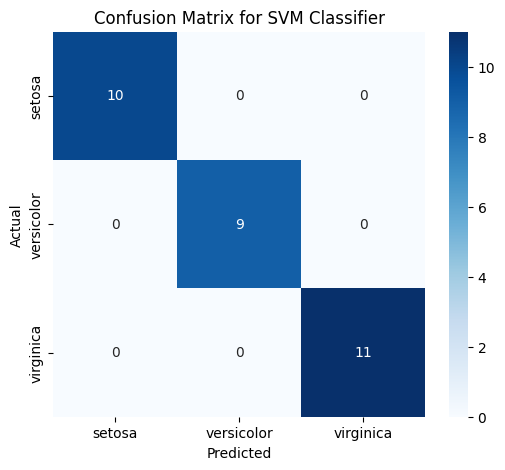

In [23]:
# 43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn=
# Import required libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1️ Load Dataset
# -----------------------------
iris = datasets.load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train SVM Classifier
# -----------------------------
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# ----------------------------
# 3️ Make Predictions
# -----------------------------
y_pred = svm_model.predict(X_test)

# -----------------------------
# 4️ Compute Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

# -----------------------------
# 5️ Visualize Confusion Matrix using seaborn
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

In [24]:
# 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute
# Error (MAE) instead of MSE=
# Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1️ Load California Housing Dataset
# -----------------------------
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Feature Scaling (important for SVR)
# -----------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1,1)).ravel()

# -----------------------------
# 3️ Train SVR Model
# -----------------------------
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# -----------------------------
# 4️ Make Predictions
# -----------------------------
y_pred_scaled = svr_model.predict(X_test_scaled)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

# -----------------------------
# 5️ Evaluate Performance using MAE
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.3739065857811119


ROC-AUC Score: 0.9983622666229938


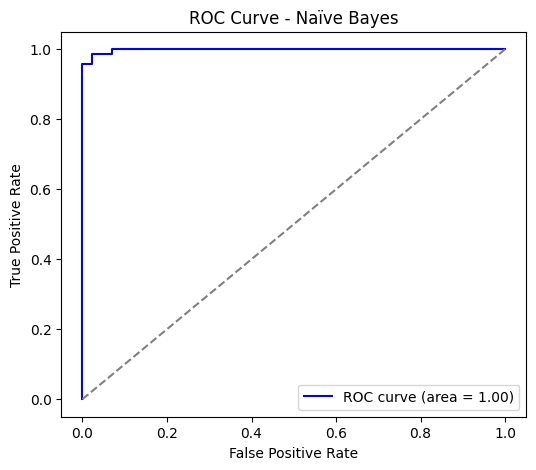

In [25]:
# 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC
# score=
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# -----------------------------
# 1️ Load Dataset
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train Naïve Bayes Classifier
# -----------------------------
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# -----------------------------
# 3️ Predict Probabilities
# ----------------------------
y_prob = gnb.predict_proba(X_test)[:, 1]  # probability of positive class

# -----------------------------
# 4️ Compute ROC-AUC Score
# -----------------------------
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# -----------------------------
# 5️ Optional: Plot ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})', color='blue')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naïve Bayes')
plt.legend(loc='lower right')
plt.show()

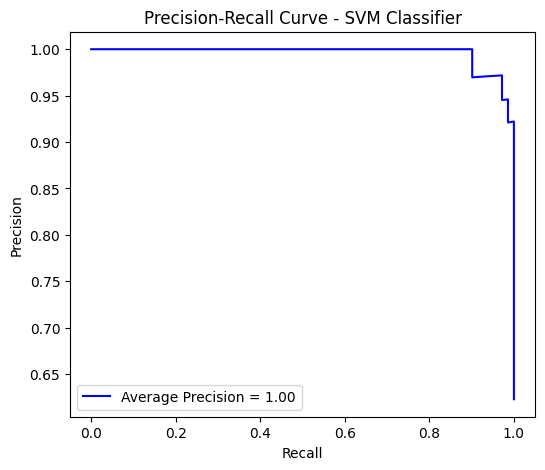

In [27]:
# 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.
# Import required libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# -----------------------------
# 1️ Load Dataset
# -----------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2️ Train SVM Classifier with probability estimates
# -----------------------------
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train, y_train)

# -----------------------------
# 3️ Predict Probabilities
# -----------------------------
y_prob = svm_model.predict_proba(X_test)[:, 1]  # probability of positive class

# -----------------------------
# 4️ Compute Precision-Recall
# -----------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# -----------------------------
# 5️ Plot Precision-Recall Curve
# -----------------------------
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label=f'Average Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM Classifier')
plt.legend()
plt.show()